# Exploratory Data Analysis - Customer Churn Dataset

This notebook performs comprehensive exploratory data analysis on the customer churn dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Add project root to path (notebooks are in notebooks/ subdirectory)
sys.path.insert(0, os.path.abspath('..'))

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [4]:
# Load the raw dataset (before preprocessing)
df = pd.read_csv('../src/data/customer_churn_datasest.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names and types:")
print(df.dtypes)

Dataset shape: (7043, 21)

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Strea

## 2. Data Overview

In [5]:
# Data info
print("Dataset Info:")
print(df.info())
print(f"\nData types:\n{df.dtypes}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [6]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Missing Values Analysis

In [7]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percent
})

print("Missing Values:")
print(missing_df[missing_df['Missing_Count'] > 0])
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

Total missing values: 0


## 4. Target Variable Analysis

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


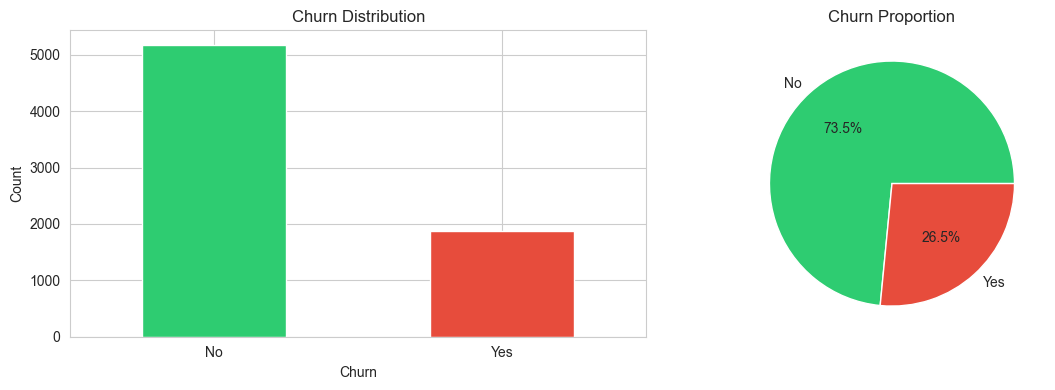

In [8]:
# Churn distribution
print("Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn'] == 'Yes').sum() / len(df) * 100:.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Proportion')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Numerical Features Analysis

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


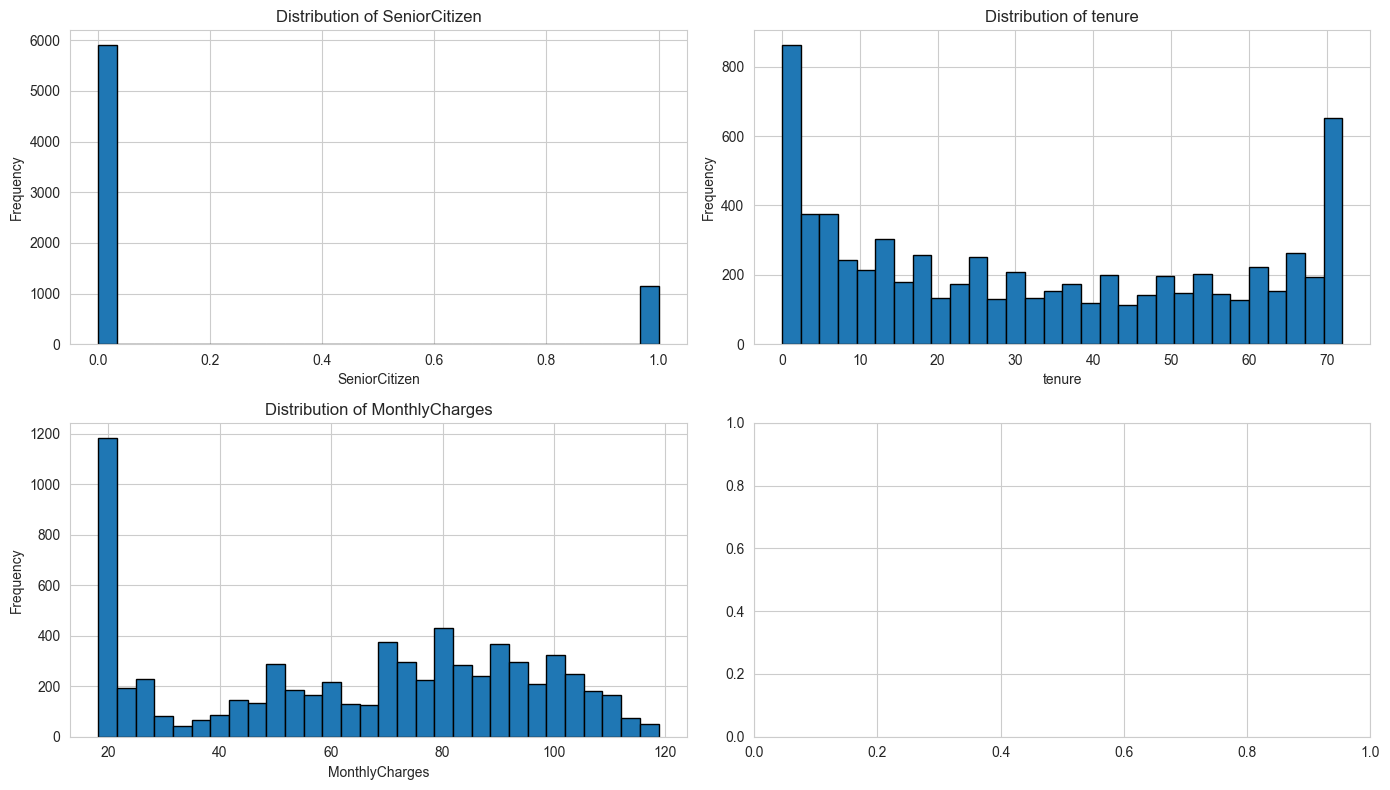

In [9]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, col in enumerate(numerical_cols[:4]):
    ax = axes[idx // 2, idx % 2]
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Categorical Features Analysis

In [10]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Value counts for categorical features
for col in categorical_cols[:5]:
    print(f"\n{col}:")
    print(df[col].value_counts())

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

customerID:
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64


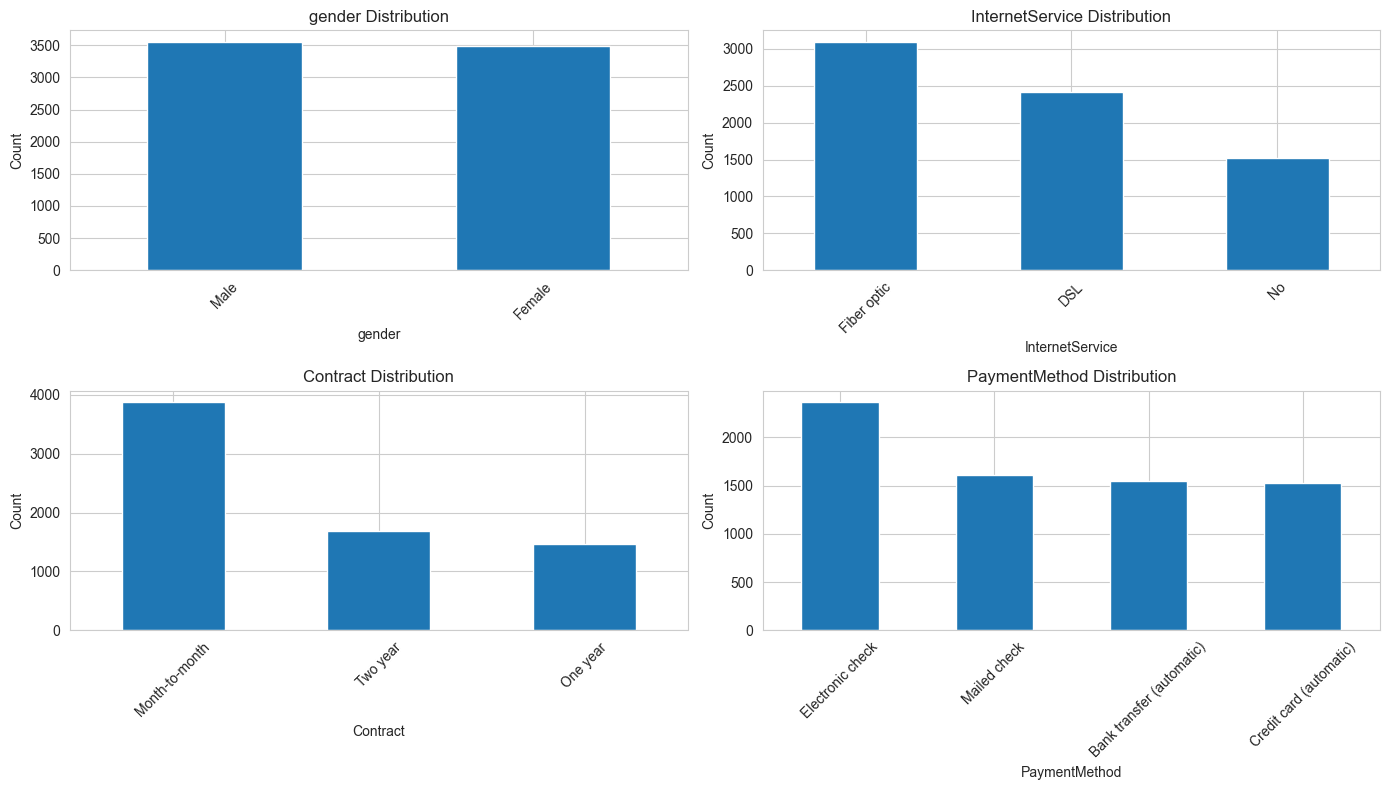

In [11]:
# Visualize categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sample_cats = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

for idx, col in enumerate(sample_cats):
    ax = axes[idx // 2, idx % 2]
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'{col} Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

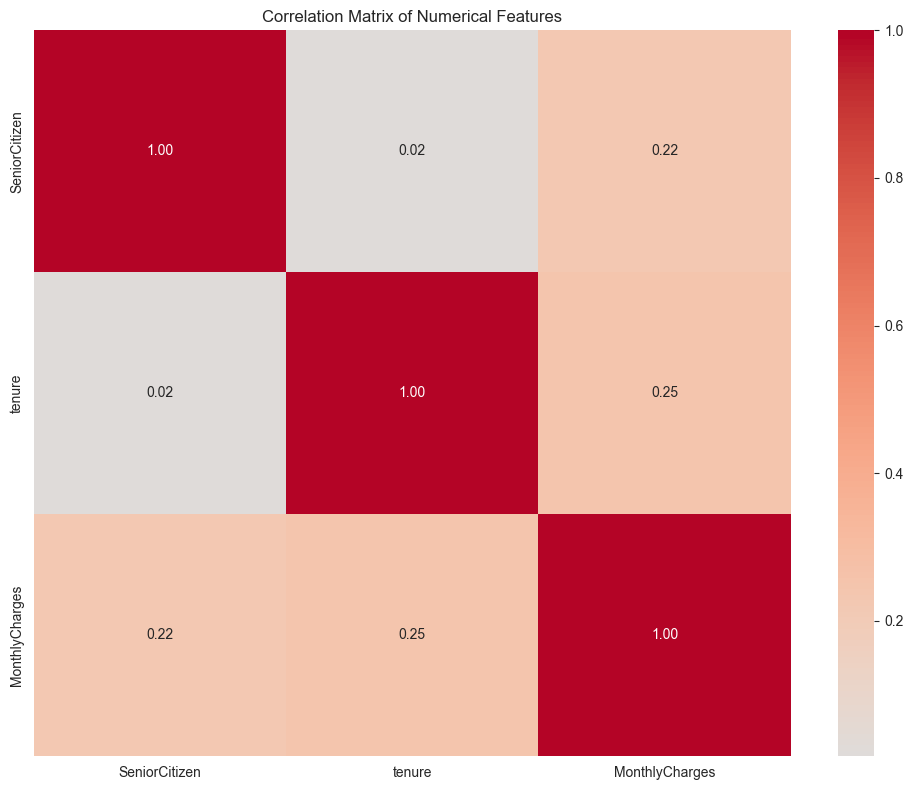

In [12]:
# Convert TotalCharges to numeric (as it might have non-numeric values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Create correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 8. Churn by Key Features

Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

Churn Rate by Internet Service:
InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64


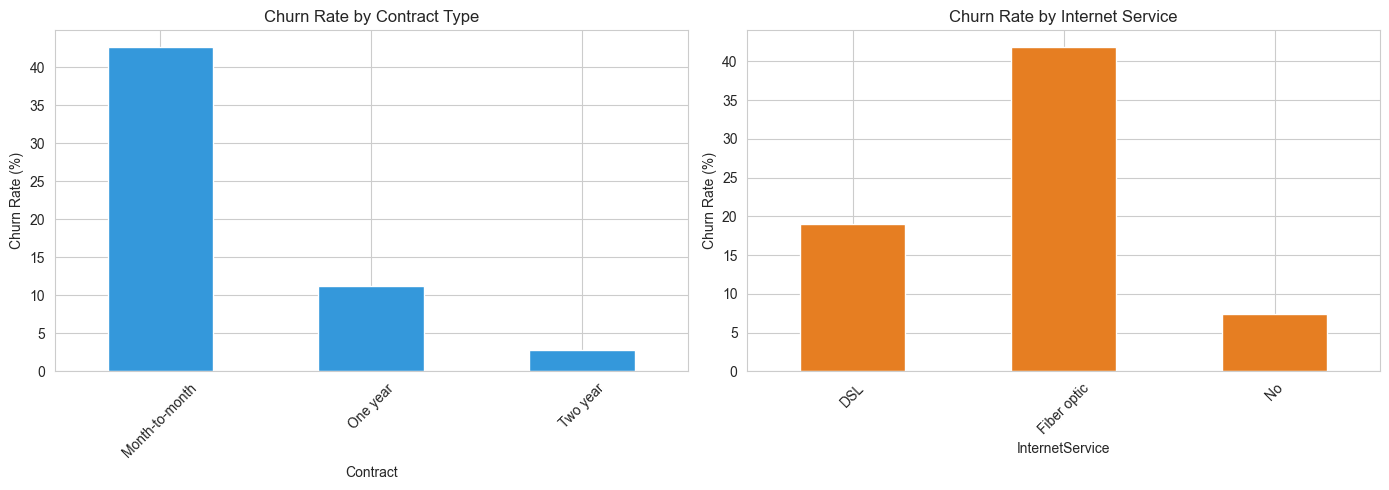

In [13]:
# Churn rate by Contract type
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
print("Churn Rate by Contract Type:")
print(churn_by_contract)

# Churn rate by Internet Service
churn_by_internet = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
print("\nChurn Rate by Internet Service:")
print(churn_by_internet)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_contract.plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

churn_by_internet.plot(kind='bar', ax=axes[1], color='#e67e22')
axes[1].set_title('Churn Rate by Internet Service')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Numerical Features vs Churn

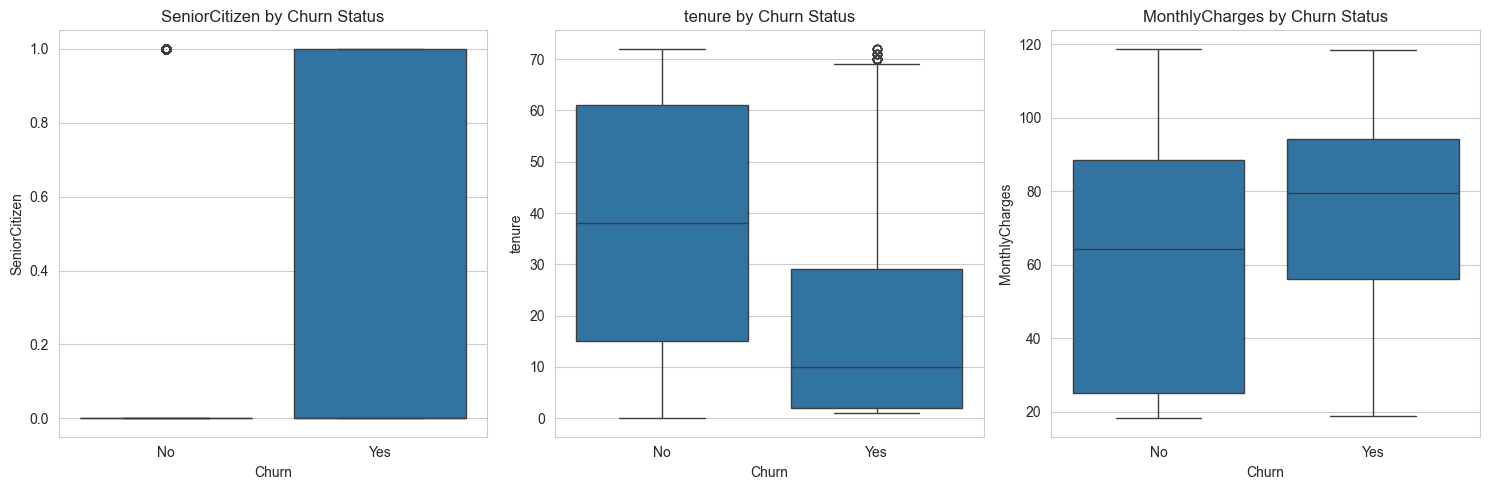

In [14]:
# Boxplots for numerical features by churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(numerical_cols[:3]):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[idx])
    axes[idx].set_title(f'{col} by Churn Status')

plt.tight_layout()
plt.show()

## 10. Key Insights Summary

In [15]:
print("=" * 60)
print("KEY INSIGHTS FROM EDA")
print("=" * 60)
print(f"\n1. Dataset Size: {df.shape[0]} customers, {df.shape[1]} features")
print(f"2. Churn Rate: {(df['Churn'] == 'Yes').sum() / len(df) * 100:.2f}%")
print(f"3. Missing Values: {df.isnull().sum().sum()}")
print(f"4. Numerical Features: {len(numerical_cols)}")
print(f"5. Categorical Features: {len(categorical_cols)}")
print(f"\n6. Highest Churn Rate Contract: {churn_by_contract.idxmax()} ({churn_by_contract.max():.2f}%)")
print(f"7. Lowest Churn Rate Contract: {churn_by_contract.idxmin()} ({churn_by_contract.min():.2f}%)")
print(f"\n8. Average Tenure (No Churn): {df[df['Churn'] == 'No']['tenure'].mean():.2f} months")
print(f"9. Average Tenure (Churn): {df[df['Churn'] == 'Yes']['tenure'].mean():.2f} months")
print("=" * 60)

KEY INSIGHTS FROM EDA

1. Dataset Size: 7043 customers, 21 features
2. Churn Rate: 26.54%
3. Missing Values: 11
4. Numerical Features: 3
5. Categorical Features: 18

6. Highest Churn Rate Contract: Month-to-month (42.71%)
7. Lowest Churn Rate Contract: Two year (2.83%)

8. Average Tenure (No Churn): 37.57 months
9. Average Tenure (Churn): 17.98 months
